# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

# Task 1

## 1.1

In [2]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [5]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

story_table = (
    df.groupby("Revenue")[story_features]
      .mean()
      .T
)

story_table.columns = ["No purchase", "Purchase"]

story_table

,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555


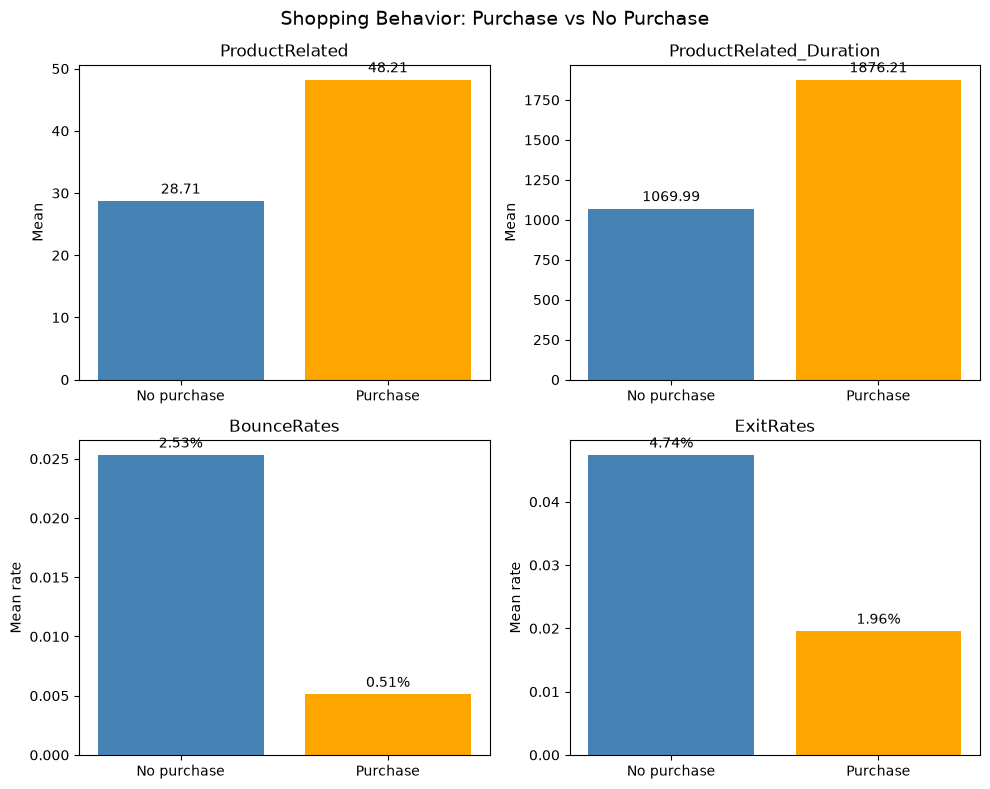

In [6]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
]

story_table = (
    df.groupby("Revenue")[story_features]
      .mean()
      .T
)

story_table.columns = ["No purchase", "Purchase"]

display(story_table)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for ax, feature in zip(axes, story_features):

    values = story_table.loc[feature]

    bars = ax.bar(
        ["No purchase", "Purchase"],
        values,
        color=["steelblue", "orange"]
    )

    # BounceRate and ExitRate are easier to understand as percentages
    if feature in ["BounceRates", "ExitRates"]:

        labels = [
            f"{value * 100:.2f}%"
            for value in values
        ]

        ax.set_ylabel("Mean rate")

    else:

        labels = [
            f"{value:.2f}"
            for value in values
        ]

        ax.set_ylabel("Mean")

    ax.bar_label(
        bars,
        labels=labels,
        padding=3
    )

    ax.set_title(feature)


fig.suptitle(
    "Shopping Behavior: Purchase vs No Purchase",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Dataset first exploration

We compared sessions that resulted in a purchase with sessions that did not.  
The clearest difference is that purchasing sessions show much stronger engagement with product pages. On average, they viewed about 48 product-related pages, compared to about 29 pages for non-purchasing sessions. They also spent much more time on these pages: around 1,876 seconds, compared to 1,070 seconds.  
At the same time, purchasing sessions had much lower bounce and exit rates. The average bounce rate decreased from about 2.53% to 0.51%, while the exit rate decreased from 4.74% to 1.96%.  
Overall, the data suggests that sessions resulting in purchases are characterized by more product exploration, longer browsing time, and lower bounce and exit rates.

## 1.2

In [7]:
df["BrowserGroup"] = np.where(
    df["Browser"] == 13,
    "Browser 13",
    "Other browsers"
)

print(df["BrowserGroup"].value_counts())

BrowserGroup
Other browsers    12269
Browser 13           61
Name: count, dtype: int64


In [8]:
story_table = (
    df.groupby("BrowserGroup")
      .mean(numeric_only=True)
      .T
)

story_table.columns = ["Other Browsers", "Browser 13"]

story_table

,Other Browsers,Browser 13
Administrative,1.754098,2.317956
Administrative_Duration,73.716530,80.853921
Informational,0.229508,0.504931
Informational_Duration,4.717486,34.620336
ProductRelated,14.885246,31.815225
ProductRelated_Duration,699.388395,1197.209080
BounceRates,0.034373,0.022131
ExitRates,0.052842,0.043024
PageValues,26.268249,5.787936
SpecialDay,0.000000,0.061733


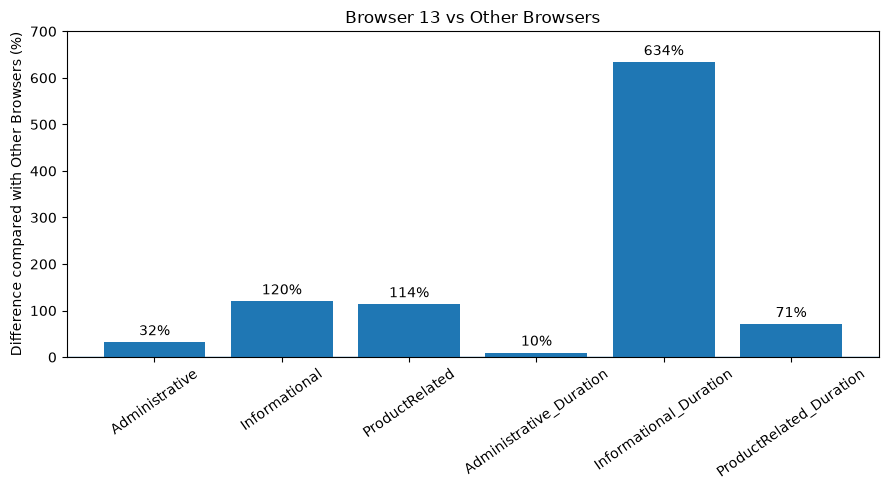

In [9]:
features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

other = story_table.loc[features, "Other Browsers"]
browser13 = story_table.loc[features, "Browser 13"]

# Percentage difference compared with Other Browsers
percentage_difference = ((browser13 - other) / other) * 100

# Create chart
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    features,
    percentage_difference
)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Difference compared with Other Browsers (%)")
ax.set_title("Browser 13 vs Other Browsers")
ax.tick_params(axis="x", rotation=35)

# Add values above/below bars
for bar, value in zip(bars, percentage_difference):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (15 if value >= 0 else -35),
        f"{value:.0f}%",
        ha="center"
    )

ax.set_ylim(0, 700)

plt.tight_layout()
plt.show()

# Task 2

### Normalization

According to the documentation, before the clustering analysis, the data frame needs to be preprocessed.  
Numerical variables will be standardized using StandardScaler, while nominal variables will be one-hot encoded. Boolean variables will be turned into 0/1 values.

In [10]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("online_shoppers_intention.csv")

# Convert boolean columns
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

# One-hot encode categorical columns
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    dtype=int
)

# Scale
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Original features:", X_scaled.shape[1])

X_scaled_cleaned = X_scaled

Original features: 75


### Functions:

- sample_data
- run_affinity_propagation
- run_dbscan
- run_birch
- print_cluster_info

In [11]:
from sklearn.cluster import AffinityPropagation, Birch, DBSCAN


def sample_data(dataframe, sample_size=500, random_state=42):
    """
    Take a random sample of the dataframe.
    """
    return dataframe.sample(
        n=min(sample_size, len(dataframe)),
        random_state=random_state)

def run_affinity_propagation(
        dataframe,
        damping=0.9,
        max_iter=300,
        convergence_iter=15,
        preference=None,
        random_state=42):
    model = AffinityPropagation(
        damping=damping,
        max_iter=max_iter,
        convergence_iter=convergence_iter,
        preference=preference,
        random_state=random_state)

    labels = model.fit_predict(dataframe)

    return model, labels


def run_dbscan(
        dataframe,
        eps=1.0,
        min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)

    labels = model.fit_predict(dataframe)

    return model, labels


def run_birch(
        dataframe,
        n_clusters=4):
    model = Birch(n_clusters=n_clusters)

    labels = model.fit_predict(dataframe)

    return model, labels


def print_cluster_info(name, labels):

    counts = pd.Series(labels).value_counts().sort_index()

    print(f"\n{name}")
    print("-" * len(name))

    for cluster, count in counts.items():
        if cluster == -1:
            print(f"Noise: {count}")
        else:
            print(
                f"Cluster {cluster}: {count}")

    n_clusters = len(set(labels) - {-1})

    print(f"Number of clusters: {n_clusters}")

# Task 3

## Affinity Propagation, DBSCAN and BIRCH clustering

Sample size: 2000
PCA dimensions: 2
Explained variance:
PC1: 5.53%
PC2: 4.13%
PC1 + PC2: 9.66%

Affinity Propagation
--------------------
Cluster 0: 9
Cluster 1: 768
Cluster 2: 376
Cluster 3: 291
Cluster 4: 485
Cluster 5: 71
Number of clusters: 6

DBSCAN
------
Noise: 28
Cluster 0: 1952
Cluster 1: 7
Cluster 2: 7
Cluster 3: 3
Cluster 4: 3
Number of clusters: 5

BIRCH
-----
Cluster 0: 3
Cluster 1: 9
Cluster 2: 319
Cluster 3: 1046
Cluster 4: 467
Cluster 5: 22
Cluster 6: 134
Number of clusters: 7


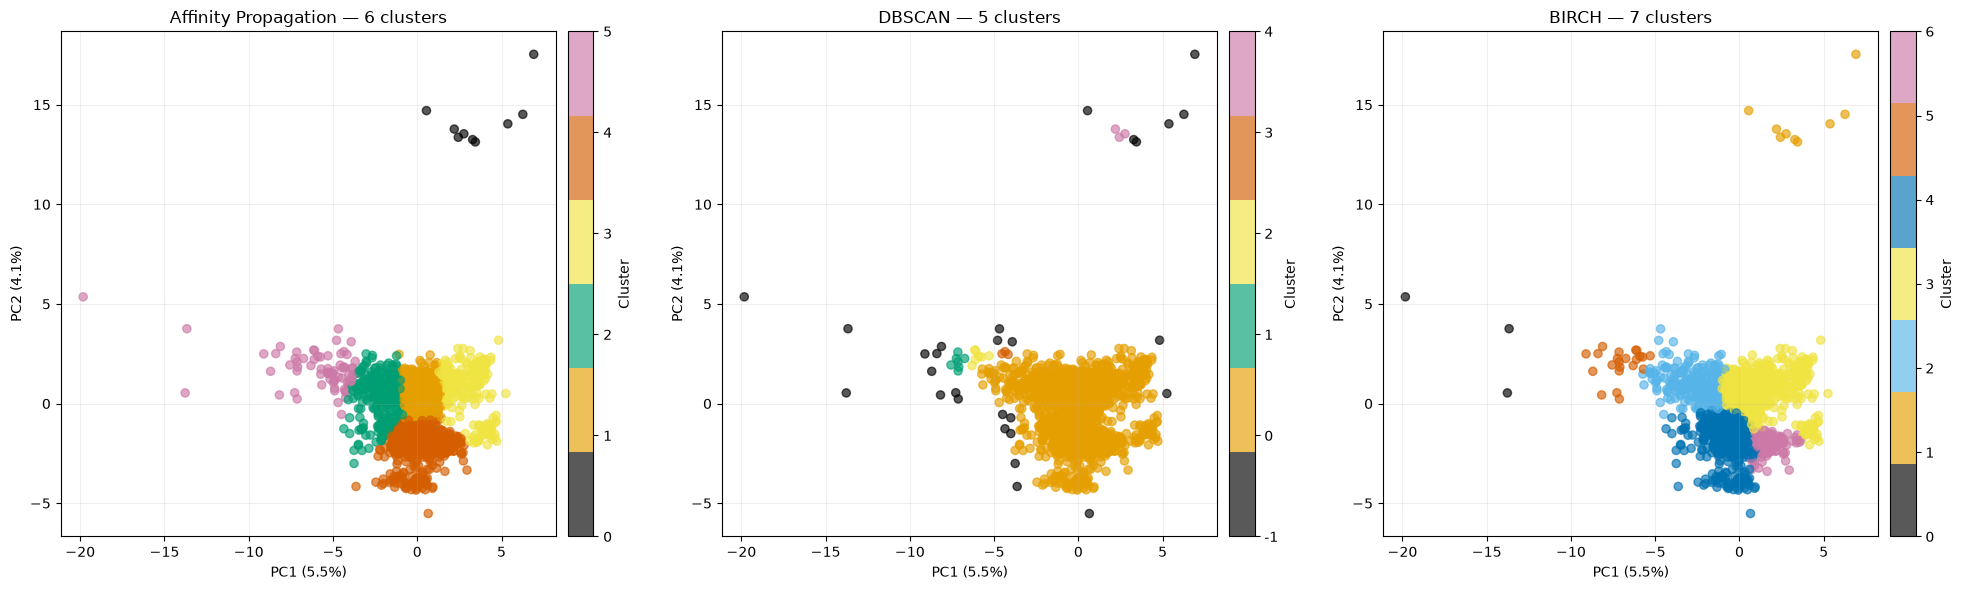

In [12]:
from sklearn.decomposition import PCA

# 1. MAKE DATAFRAME
df_scaled_cleaned = pd.DataFrame(X_scaled_cleaned, columns=df.columns)

# 2. SAMPLE THE DATA
df_sample = sample_data(df_scaled_cleaned, sample_size=2000, random_state=42)

print("Sample size:", len(df_sample))

# 3. PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(df_sample)

print("PCA dimensions:", X_pca.shape[1])

print("Explained variance:")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance * 100:.2f}%")

print("PC1 + PC2:", f"{pca.explained_variance_ratio_[:2].sum() * 100:.2f}%")

# 4. RUN AFFINITY PROPAGATION
af, labels_ap = run_affinity_propagation(
    X_pca,
    damping=0.9,
    preference=-1000,
    max_iter=300,
    convergence_iter=15,
    random_state=42,)

# 5. RUN DBSCAN
dbscan, labels_dbscan = run_dbscan(X_pca, eps=0.55, min_samples=3)

# 6. RUN BIRCH
brc, labels_birch = run_birch(X_pca, n_clusters=7)

# 7. PRINT CLUSTER INFORMATION
print_cluster_info("Affinity Propagation", labels_ap)
print_cluster_info("DBSCAN", labels_dbscan)
print_cluster_info("BIRCH", labels_birch)

# 8. PLOT
results = [
    ("Affinity Propagation", labels_ap),
    ("DBSCAN", labels_dbscan),
    ("BIRCH", labels_birch)
    ]

pc1_ratio = pca.explained_variance_ratio_[0] * 100
pc2_ratio = pca.explained_variance_ratio_[1] * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, labels) in zip(axes, results):

    unique_labels = sorted(set(labels))

    n_clusters = len([label for label in unique_labels if label != -1])

    label_map = {label: i for i, label in enumerate(unique_labels)}

    colors = [label_map[label] for label in labels]

    cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=colors,
        cmap=cmap,
        alpha=0.65,
        s=35)

    ax.set_xlabel(f"PC1 ({pc1_ratio:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2_ratio:.1f}%)")
    ax.set_title(f"{name} — {n_clusters} clusters")
    ax.grid(alpha=0.2)

    colorbar = fig.colorbar(
        scatter,
        ax=ax,
        ticks=range(len(unique_labels)),
        pad=0.02)

    colorbar.set_label("Cluster")
    colorbar.set_ticklabels(unique_labels)

plt.tight_layout()
plt.show()

The PC dimensionality reduction method resulted in the same object placements in all 3 plots. Affinity Propagation, DBSCAN and BIRCH however all resulted in different classification results. The dimensionality (number of components) was set to 2. These 2 principal components (PCA 1, PCA2) were used for the visualisations. For each visualisation, PC1 explains 5.5% of the variance, and PC2 explains 4.1% of the variance. The combined value is 9.7% which is not really high. Only the DBSCAN plot has noise (labeled as -1).

# Task 4

## 4.1: Silhouette Score

In [13]:
import math

def calculate_silhouette(labels):

    n = len(labels)

    a = [0] * n
    b = [0] * n
    s = [0] * n

    # Find unique clusters manually
    clusters = []

    for i in range(n):
        if labels[i] not in clusters:
            clusters.append(labels[i])

    # Calculate a(i), b(i), and s(i)
    for i in range(n):

        own_cluster = labels[i]

        # a(i), Average distance to own cluster
        total_distance = 0
        count = 0

        for j in range(n):
            if labels[j] == own_cluster and j != i:
                total_distance += distance_matrix[i][j]
                count += 1

        if count > 0:
            a[i] = total_distance / count
        else:
            a[i] = 0

        # b(i), Minimum average distance to another cluster

        minimum_average = float("inf")

        for cluster in clusters:
            if cluster == own_cluster:
                continue

            total_distance = 0
            count = 0

            for j in range(n):
                if labels[j] == cluster:
                    total_distance += distance_matrix[i][j]
                    count += 1

            if count > 0:
                average_distance = total_distance / count
                if average_distance < minimum_average:
                    minimum_average = average_distance

        b[i] = minimum_average

        # s(i)
        if a[i] < b[i]:
            s[i] = (b[i] - a[i]) / b[i]
        elif a[i] > b[i]:
            s[i] = (b[i] - a[i]) / a[i]
        else:
            s[i] = 0

    # Overall silhouette score
    total_s = 0

    for i in range(n):
        total_s += s[i]

    average_silhouette = total_s / n

    return a, b, s, average_silhouette

# Calculate the Euclidean distance between every pair of data points
# and store all distances in the distance matrix.

def euclidean_distance(x, y):
    assert(len(x) == len(y))
    # Start the distance at 0
    distance = 0
    for xi, yi in zip(x, y):
        distance += (xi - yi) ** 2
    return math.sqrt(distance)

distance_matrix = []

# Go through each data point
for pt1 in X_pca:
    # Create a row to store distances from point i to all other points
    row = []
    # Compare point i with every other data point
    for pt2 in X_pca:
        # Add the distance to the current row
        row.append(euclidean_distance(pt1, pt2))
    # Add the completed row to the distance matrix
    distance_matrix.append(row)


a_ap, b_ap, s_ap, silhouette_ap = calculate_silhouette(labels_ap)
a_db, b_db, s_db, silhouette_db = calculate_silhouette(labels_dbscan)
a_birch, b_birch, s_birch, silhouette_birch = calculate_silhouette(labels_birch)

# No predefined functions or libraries allowed:
print("+----------------------+-------------------+------------------------+")
print("| Method               | Silhouette Score  | Interpretation         |")
print("+----------------------+-------------------+------------------------+")
print(f"| Affinity Propagation | {silhouette_ap:<17.3f} | Weak Cluster Structure |")
print(f"| DBSCAN               | {silhouette_db:<17.3f} | Weak Cluster Structure |")
print(f"| BIRCH                | {silhouette_birch:<17.3f} | Weak Cluster Structure |")
print("+----------------------+-------------------+------------------------+")

+----------------------+-------------------+------------------------+
| Method               | Silhouette Score  | Interpretation         |
+----------------------+-------------------+------------------------+
| Affinity Propagation | 0.401             | Weak Cluster Structure |
| DBSCAN               | 0.419             | Weak Cluster Structure |
| BIRCH                | 0.343             | Weak Cluster Structure |
+----------------------+-------------------+------------------------+


## 4.2: Davies Bouldin Score 

In [14]:
from sklearn.metrics import davies_bouldin_score

def calculate_davies_bouldin(X, labels):
    """
    Calculate the Davies-Bouldin Score for a clustering result.

    Parameters:
        X      : Data points used for clustering
        labels : Cluster labels assigned to each data point

    Returns:
        Davies-Bouldin Score
    """
    return davies_bouldin_score(X, labels)

# Calculate Davies-Bouldin Score for each clustering model
db_ap = calculate_davies_bouldin(X_pca, labels_ap)
db_dbscan = calculate_davies_bouldin(X_pca, labels_dbscan)
db_birch = calculate_davies_bouldin(X_pca, labels_birch)

# Display the results
print("+----------------------+-----------------------+------------------------+")
print("| Method               | Davies-Bouldin Score  | Interpretation         |")
print("+----------------------+-----------------------+------------------------+")
print(f"| Affinity Propagation | {db_ap:<21.3f} | Good                   |")
print(f"| DBSCAN               | {db_dbscan:<21.3f} | Weak                   |")
print(f"| BIRCH                | {db_birch:<21.3f} | Good                   |")
print("+----------------------+-----------------------+------------------------+")

+----------------------+-----------------------+------------------------+
| Method               | Davies-Bouldin Score  | Interpretation         |
+----------------------+-----------------------+------------------------+
| Affinity Propagation | 0.693                 | Good                   |
| DBSCAN               | 3.268                 | Weak                   |
| BIRCH                | 0.634                 | Good                   |
+----------------------+-----------------------+------------------------+


## 4.3: Calinski-Harabasz Index 

In [15]:
from sklearn.metrics import calinski_harabasz_score

def calculate_calinski_harabasz(X, labels):
    """
    Calculate the Calinski-Harabasz Index for a clustering result.

    Parameters:
        X      : Data points used for clustering
        labels : Cluster labels assigned to each data point

    Returns:
        Calinski-Harabasz Index
    """
    return calinski_harabasz_score(X, labels)

# Calculate Calinski-Harabasz Index for each clustering model
ch_ap = calculate_calinski_harabasz(X_pca, labels_ap)
ch_dbscan = calculate_calinski_harabasz(X_pca, labels_dbscan)
ch_birch = calculate_calinski_harabasz(X_pca, labels_birch)

# Display the results
print("+----------------------+-------------------------+------------------------+")
print("| Method               | Calinski-Harabasz Index | Interpretation         |")
print("+----------------------+-------------------------+------------------------+")
print(f"| Affinity Propagation | {ch_ap:<23.3f} | Strong                 |")
print(f"| DBSCAN               | {ch_dbscan:<23.3f} | Weak                   |")
print(f"| BIRCH                | {ch_birch:<23.3f} | Good                   |")
print("+----------------------+-------------------------+------------------------+")


+----------------------+-------------------------+------------------------+
| Method               | Calinski-Harabasz Index | Interpretation         |
+----------------------+-------------------------+------------------------+
| Affinity Propagation | 1348.003                | Strong                 |
| DBSCAN               | 68.703                  | Weak                   |
| BIRCH                | 812.971                 | Good                   |
+----------------------+-------------------------+------------------------+


# Task 5

## 5.1: Euclidean distance + DBSCAN

The Euclidean distance function was manually implemented in task 4.1.  
Since the function does not use any predefined distance functions or libraries, we reuse the same implementation here as the distance metric for DBSCAN.

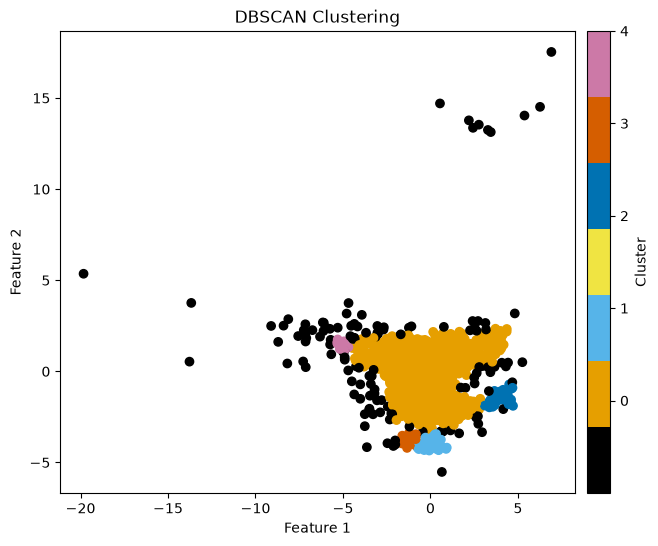

In [16]:
dbscan = DBSCAN(
    eps=0.4,
    min_samples=10,
    metric=euclidean_distance)

labels_euclidean = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_euclidean,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("DBSCAN Clustering")

plt.show()

## 5.2: Manhattan distance + DBSCAN

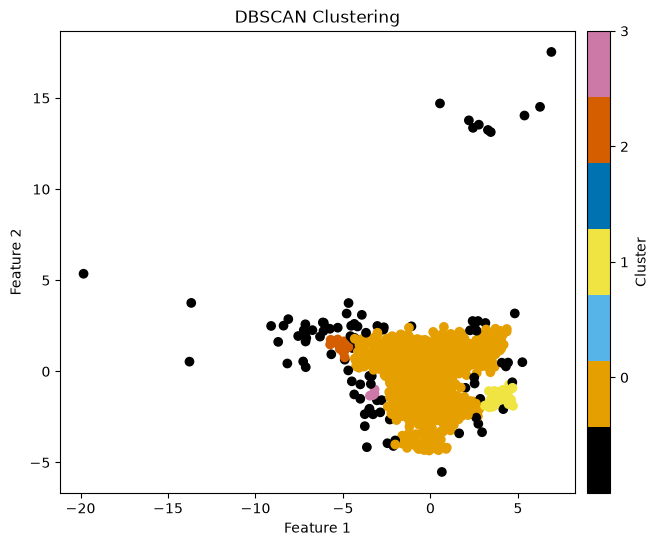

In [17]:
def manhattan_distance(point1, point2):
    assert(len(point1) == len(point2))
    distance = 0
    for x1, x2 in zip(point1, point2):
        distance += abs(x1 - x2)
    return distance

dbscan = DBSCAN(
    eps=0.5,
    min_samples=6,
    metric=manhattan_distance)

labels_manhattan = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_manhattan,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("DBSCAN Clustering")

plt.show()

## 5.3: Cosine similarity distance + DBSCAN

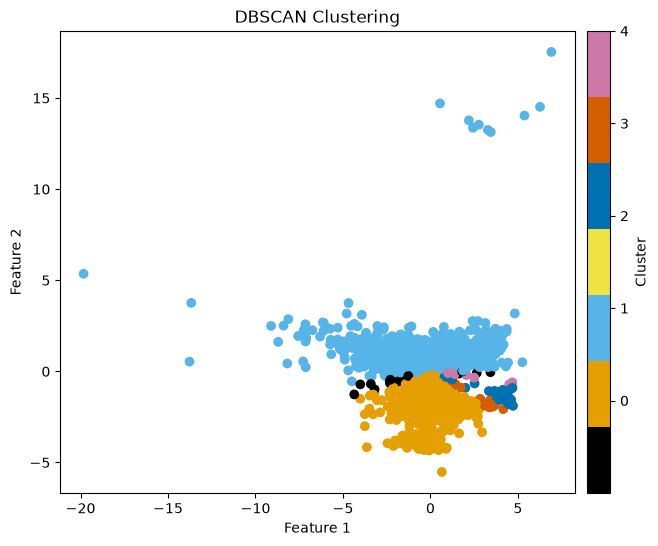

In [18]:
def cosine_distance(point1, point2):
    dot_product = 0
    magnitude1 = 0
    magnitude2 = 0

    for x1, x2 in zip(point1, point2):
        dot_product += x1 * x2
        magnitude1 += x1 * x1
        magnitude2 += x2 * x2

    magnitude1 = math.sqrt(magnitude1)
    magnitude2 = math.sqrt(magnitude2)

    if magnitude1 == 0 or magnitude2 == 0:
        return 0

    cosine_similarity = dot_product / (magnitude1 * magnitude2)

    return 1 - cosine_similarity

dbscan = DBSCAN(
    eps=0.001,
    min_samples=15,
    metric=cosine_distance)

labels_cosine = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_cosine,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("DBSCAN Clustering")

plt.show()

## 5.4: Evaluate different distance functions

In [19]:
# Calculate silhouette values for each distance function
from numpy import iterable


score_euclidean = calculate_silhouette(labels_euclidean)
score_manhattan = calculate_silhouette(labels_manhattan)
score_cosine = calculate_silhouette(labels_cosine)

def flatten_list(l):
    flatened_l = []
    for val in l:
        if iterable(val):
            flatened_l.extend(val)
        else:
            flatened_l.append(val)
    return flatened_l

# Flatten the results (remove nested lists)
flat_euclidean = flatten_list(score_euclidean)
flat_manhattan = flatten_list(score_manhattan)
flat_cosine = flatten_list(score_cosine)


# Calculate the average silhouette score
average_euclidean = sum(flat_euclidean) / len(flat_euclidean)
average_manhattan = sum(flat_manhattan) / len(flat_manhattan)
average_cosine = sum(flat_cosine) / len(flat_cosine)


# Print the results
print("Euclidean silhouette score:", average_euclidean)
print("Manhattan silhouette score:", average_manhattan)
print("Cosine silhouette score:", average_cosine)

#Interpretation:
# s > 0.7: strong cluster structure
# s > 0.5: reasonable cluster structure
# s > 0.25: weak cluster structure
# s < 0.25: no cluster structure

Euclidean silhouette score: 2.04300417058194
Manhattan silhouette score: 2.0495227072360955
Cosine silhouette score: 1.5562145382302446


Visualisation of the different silhouette scores

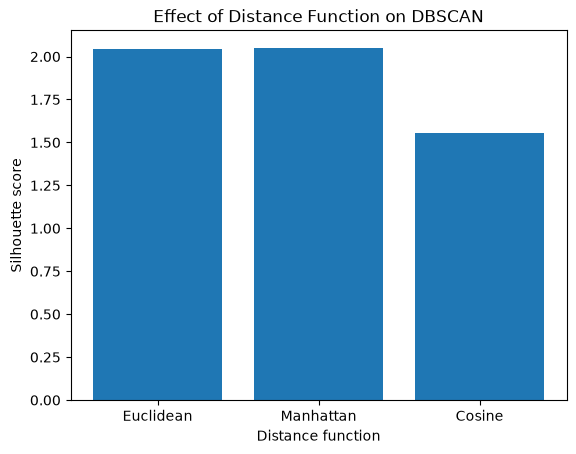

In [20]:
distance_functions = ["Euclidean", "Manhattan", "Cosine"]
silhouette_scores = [
    average_euclidean,
    average_manhattan,
    average_cosine
    ]

plt.bar(distance_functions, silhouette_scores)

plt.xlabel("Distance function")
plt.ylabel("Silhouette score")
plt.title("Effect of Distance Function on DBSCAN")

plt.show()